# 04 — Combat Statistics

> **Key question**: What is the value range of each stat, and which types dominate in each combat role?

Understanding stat ranges helps us identify what "excellent" looks like for each attribute,
and which types to prioritise depending on the team role we need to fill.

**Prerequisite**: run `01_data_loading_cleaning.ipynb` first.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle

plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.facecolor': '#F5F6FA', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
})

STATS = ['hp', 'attack', 'defense', 'special-attack', 'special-defense', 'speed']
STAT_LABELS = {
    'hp': 'HP', 'attack': 'Attack', 'defense': 'Defense',
    'special-attack': 'Sp. Atk', 'special-defense': 'Sp. Def', 'speed': 'Speed'
}
STAT_COLORS = ['#E74C3C', '#E67E22', '#3498DB', '#9B59B6', '#1ABC9C', '#F1C40F']
TYPE_COLORS = {
    'normal': '#A8A878', 'fire': '#F08030', 'water': '#6890F0', 'electric': '#F8D030',
    'grass': '#78C850', 'ice': '#98D8D8', 'fighting': '#C03028', 'poison': '#A040A0',
    'ground': '#E0C068', 'flying': '#A890F0', 'psychic': '#F85888', 'bug': '#A8B820',
    'rock': '#B8A038', 'ghost': '#705898', 'dragon': '#7038F8', 'dark': '#705848',
    'steel': '#B8B8D0', 'fairy': '#EE99AC',
}

with open('../data/pokemon_processed.pkl', 'rb') as f:
    df = pickle.load(f)
print(f'Data loaded: {df.shape[0]} Pokémon')

Data loaded: 1025 Pokémon


## 1. Distribution of the 6 base stats — What is a good value?

Each histogram shows the range of values for one stat across all Pokémon.
The coloured zone marks the **top 25%** — those are the values we should aim for in our team.


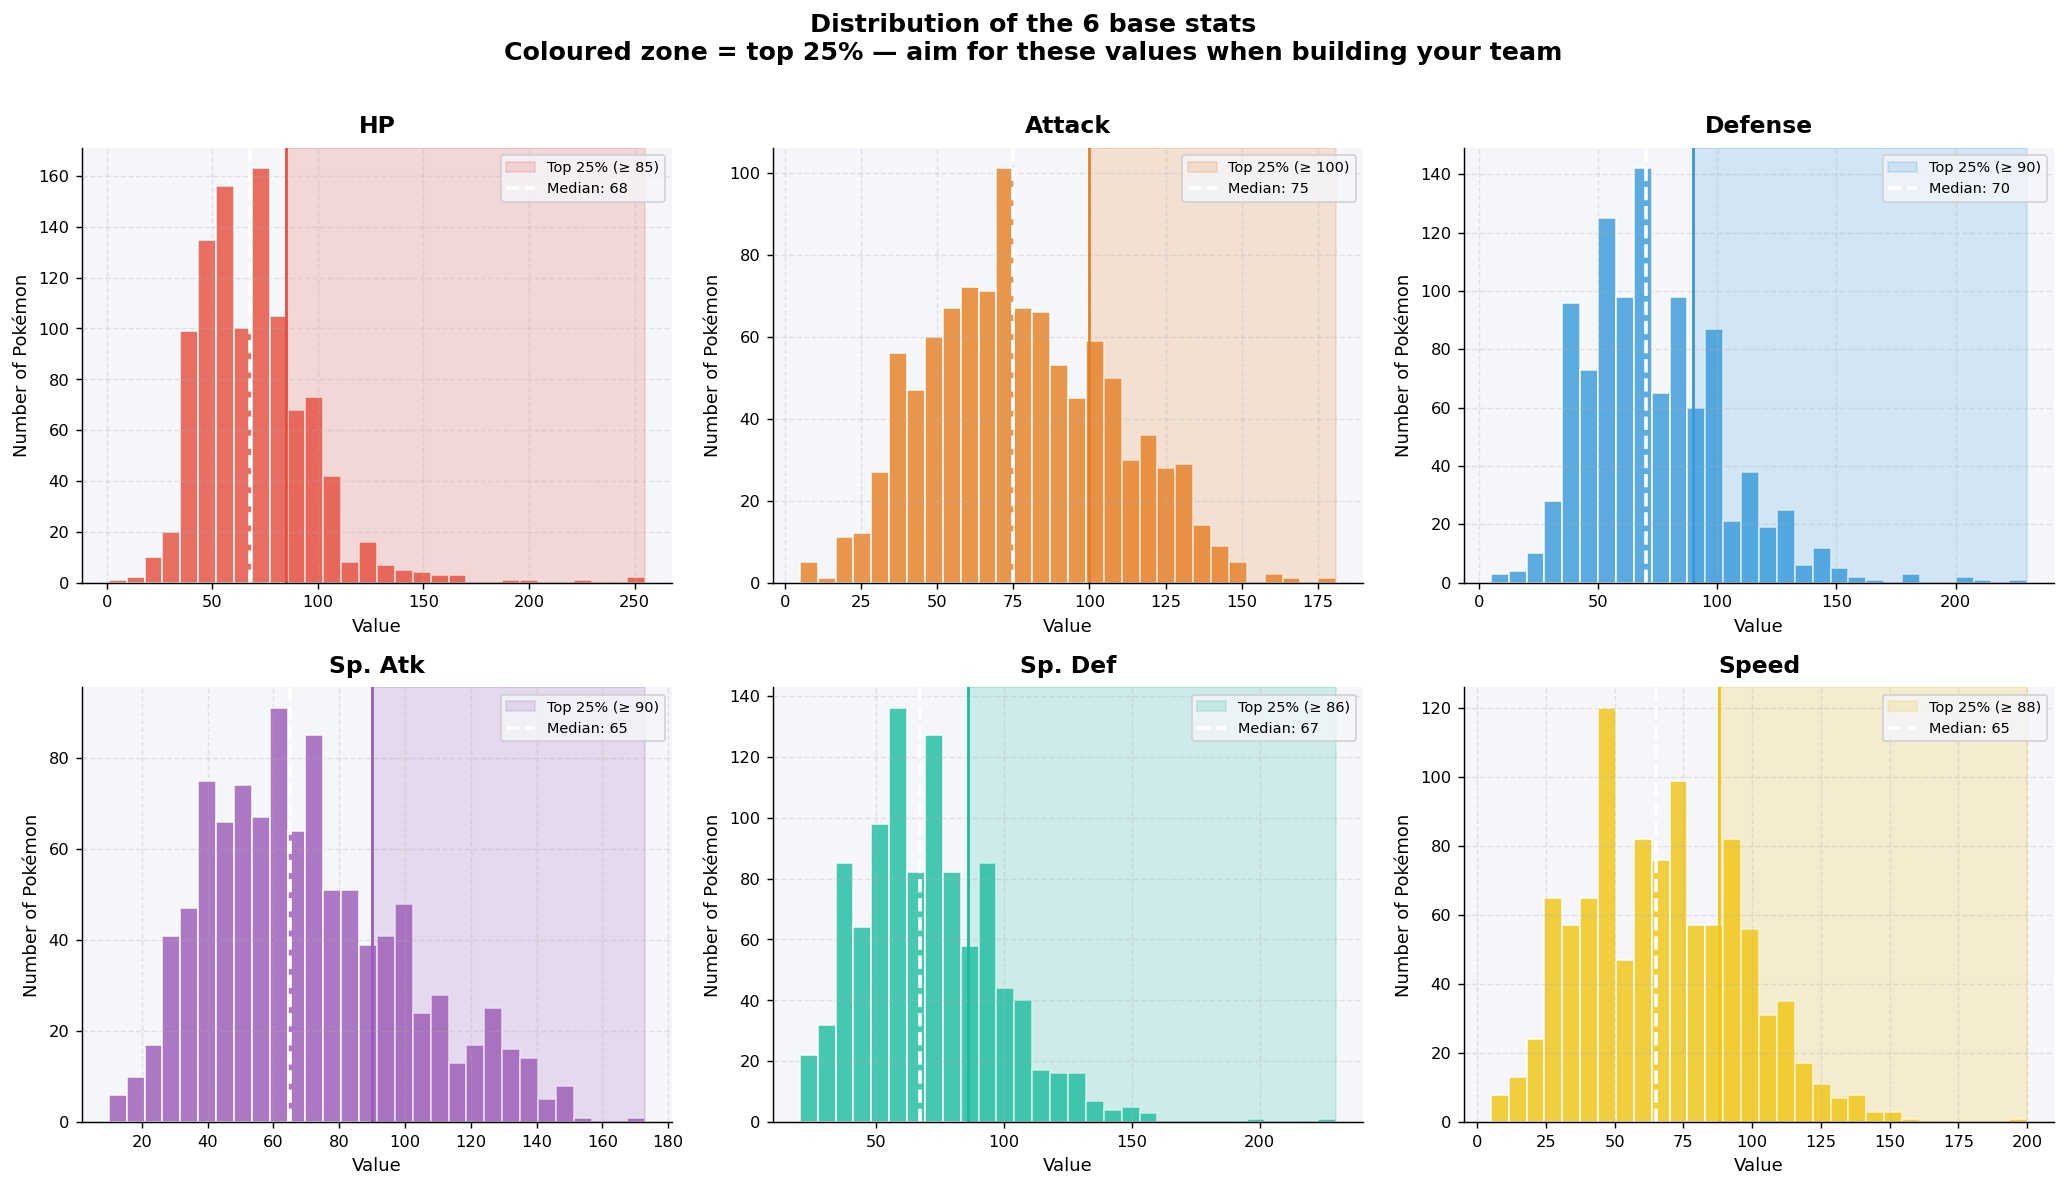

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, stat, color in zip(axes, STATS, STAT_COLORS):
    data = df[stat].dropna()
    q75  = data.quantile(0.75)
    med  = data.median()

    ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.80)

    ax.axvspan(q75, data.max(), alpha=0.18, color=color,
               label=f'Top 25% (≥ {q75:.0f})')
    ax.axvline(med, color='white', linestyle='--', linewidth=2,
               label=f'Median: {med:.0f}')
    ax.axvline(q75, color=color, linestyle='-', linewidth=1.5)

    ax.set_title(STAT_LABELS[stat], pad=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Number of Pokémon')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    'Distribution of the 6 base stats\nColoured zone = top 25%',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## 2. Average stats heatmap by type — Complete role overview


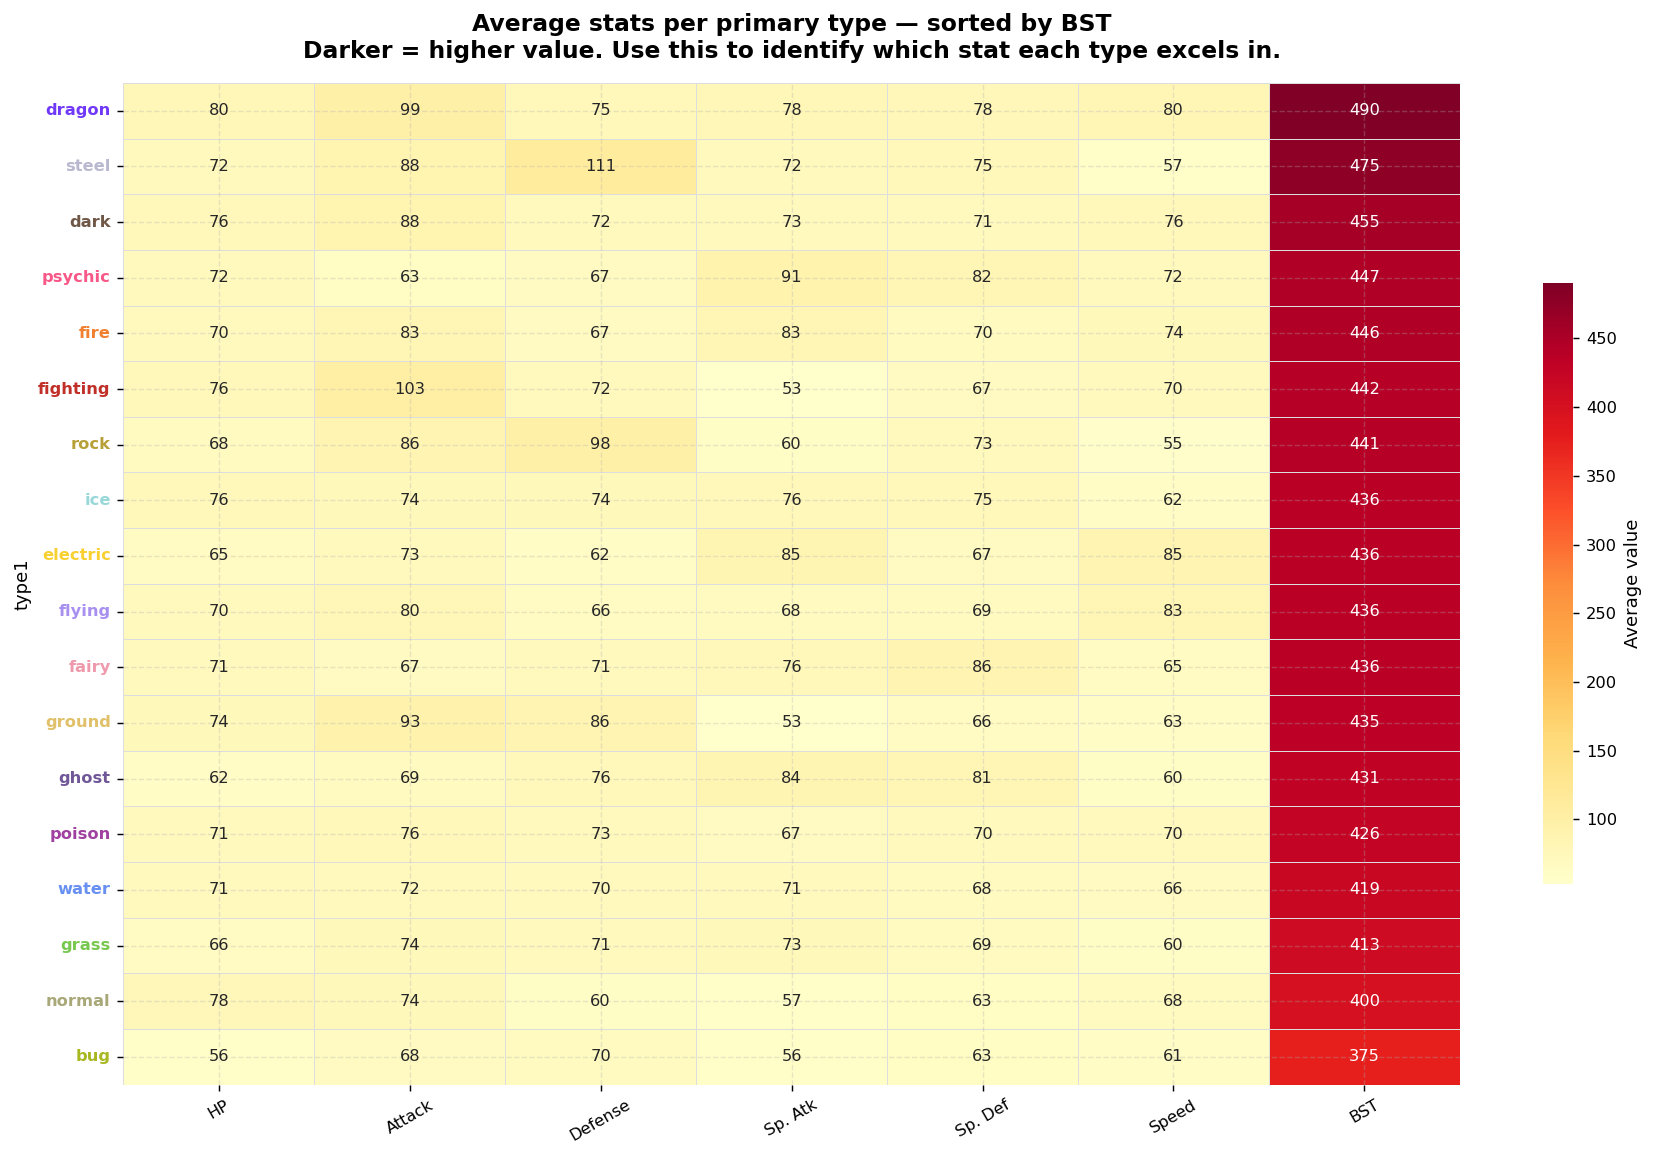

In [ ]:
hm_data = df.groupby('type1')[STATS].mean().round(1)
hm_data.columns = [STAT_LABELS[s] for s in STATS]
hm_data['BST'] = df.groupby('type1')['bst'].mean().round(1)
hm_data = hm_data.sort_values('BST', ascending=False)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    hm_data,
    annot=True, fmt='.0f', annot_kws={'size': 9},
    cmap='YlOrRd',
    linewidths=0.4, linecolor='#ddd',
    ax=ax,
    cbar_kws={'shrink': 0.6, 'label': 'Average value'}
)
ax.set_title(
    'Average stats per primary type — sorted by BST\n'
    'Darker = higher value. Use this to identify which stat each type excels in.',
    pad=14
)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
for i, t in enumerate(hm_data.index):
    ax.get_yticklabels()[i].set_color(TYPE_COLORS.get(t, '#333'))
    ax.get_yticklabels()[i].set_fontweight('bold')
plt.tight_layout()
plt.show()